In [58]:
# Importing the Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mode
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from imblearn.over_sampling import RandomOverSampler

In [7]:
# Loading the Data
data = pd.read_csv('Disease Prediction.csv')

In [9]:
# Analyse the Top 5 rows of the Data
data.head()

,fever,headache,nausea,vomiting,fatigue,joint_pain,skin_rash,cough,weight_loss,yellow_eyes,disease
0,1,0,1,0,1,0,0,1,1,0,Paralysis (brain hemorrhage)
1,0,0,1,0,0,0,1,1,0,0,Paralysis (brain hemorrhage)
2,0,0,1,0,1,0,1,1,0,0,Paralysis (brain hemorrhage)
3,0,0,1,1,1,0,1,1,1,1,Paralysis (brain hemorrhage)
4,1,0,1,0,1,0,0,0,1,1,Paralysis (brain hemorrhage)


In [11]:
encoder = LabelEncoder()
data['disease'] = encoder.fit_transform(data['disease'])

In [13]:
data.head()

,fever,headache,nausea,vomiting,fatigue,joint_pain,skin_rash,cough,weight_loss,yellow_eyes,disease
0,1,0,1,0,1,0,0,1,1,0,29
1,0,0,1,0,0,0,1,1,0,0,29
2,0,0,1,0,1,0,1,1,0,0,29
3,0,0,1,1,1,0,1,1,1,1,29
4,1,0,1,0,1,0,0,0,1,1,29


In [23]:
X = data.iloc[:,:-1]

In [25]:
y = data.iloc[:,-1]

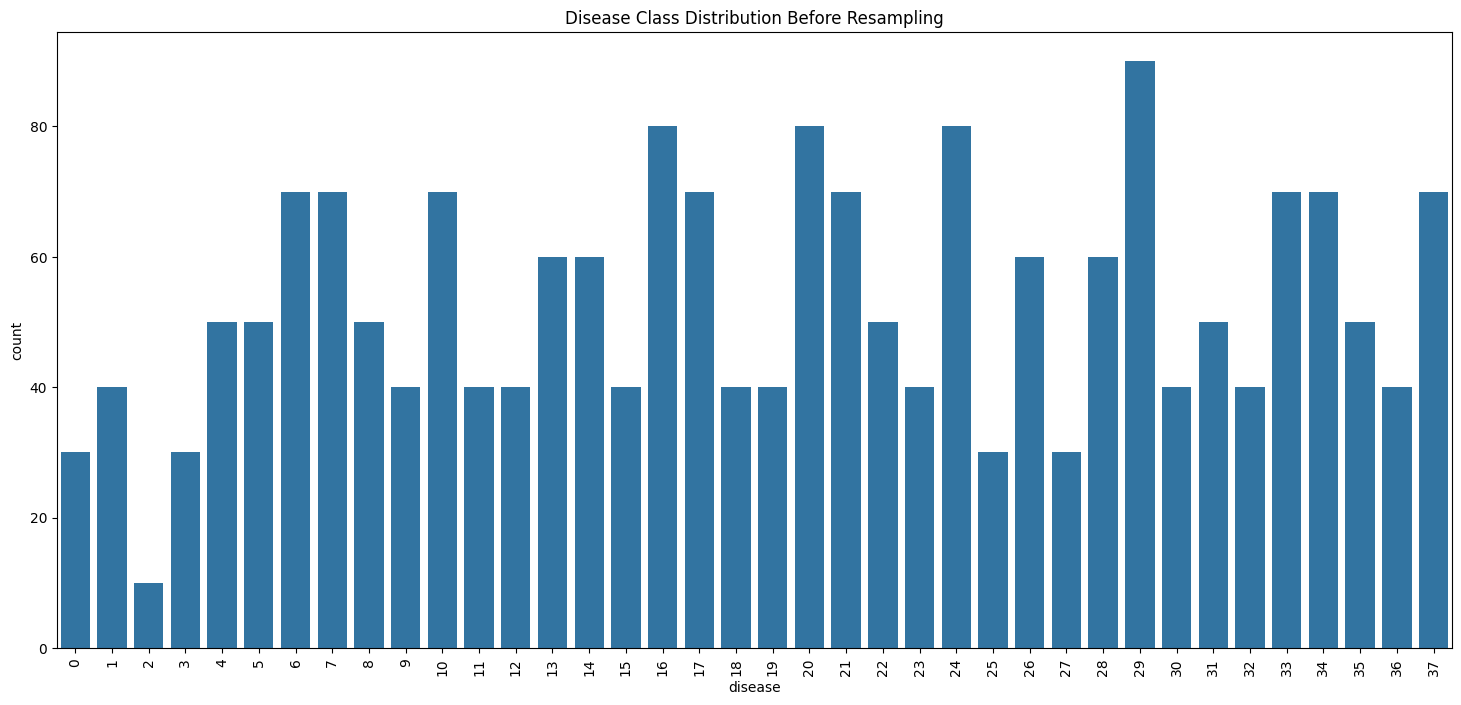

Resampled Class Distribution: 
 disease
29    90
11    90
4     90
18    90
23    90
1     90
12    90
30    90
32    90
9     90
20    90
36    90
15    90
19    90
27    90
3     90
25    90
0     90
5     90
22    90
35    90
31    90
16    90
24    90
7     90
17    90
34    90
10    90
37    90
6     90
33    90
21    90
26    90
13    90
28    90
14    90
8     90
2     90
Name: count, dtype: int64


In [43]:
plt.figure(figsize = (18,8))
sns.countplot(x=y)
plt.title('Disease Class Distribution Before Resampling')
plt.xticks(rotation = 90)
plt.show()

ros = RandomOverSampler(random_state = 42)
X_resampleed, y_resampled = ros.fit_resample(X , y)

print("Resampled Class Distribution: \n", pd.Series(y_resampled).value_counts())

#### Cross Validation with Stratified K - Fold

In [88]:
if 'gender' in X_resampleed.columns:
    le = LabelEncoder()
    X_resampleed['gender'] = le.fit_transform(X_resampleed['gender'])

X_resampleed = X_resampleed.fillna(0)

if len(y_resampled.shape) > 1:
    y_resampled = y_resampled.values.ravel()

models = {
    "SVM": SVC(),
    "Gaussian": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

cv_scoring = 'accuracy'
stratified_kfold = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

for model_name, model in models.items():
    try:
        scores = cross_val_score(
            model,
            X_resampleed,
            y_resampled,
            cv = stratified_kfold,
            scoring = cv_scoring,
            n_jobs = -1,
            error_score = 'raise'
        )

        print("=" * 50)
        print(f"Model: {model_name}")
        print(f"Scores: {scores}")
        print(f"Mean Accuracy: {scores.mean():.4f}")
    except Exception as e:
        print("=" * 50)
        print(f"Model: {model_name} failed with error:")
        print(e)

Model: SVM
Scores: [0.51315789 0.51169591 0.49707602 0.48245614 0.49561404]
Mean Accuracy: 0.5000
Model: Gaussian
Scores: [0.36403509 0.17982456 0.3625731  0.33479532 0.37134503]
Mean Accuracy: 0.3225
Model: Decision Tree
Scores: [0.5497076  0.54239766 0.5380117  0.53654971 0.52631579]
Mean Accuracy: 0.5386
Model: Random Forest
Scores: [0.56140351 0.54824561 0.54824561 0.5380117  0.52923977]
Mean Accuracy: 0.5450


#### Training Individual Models and Generating Confusion Matrices

In [72]:
svm_model = SVC()
svm_model.fit(X_resampleed, y_resampled)
svm_preds = svm_model.predict(X_resampleed)

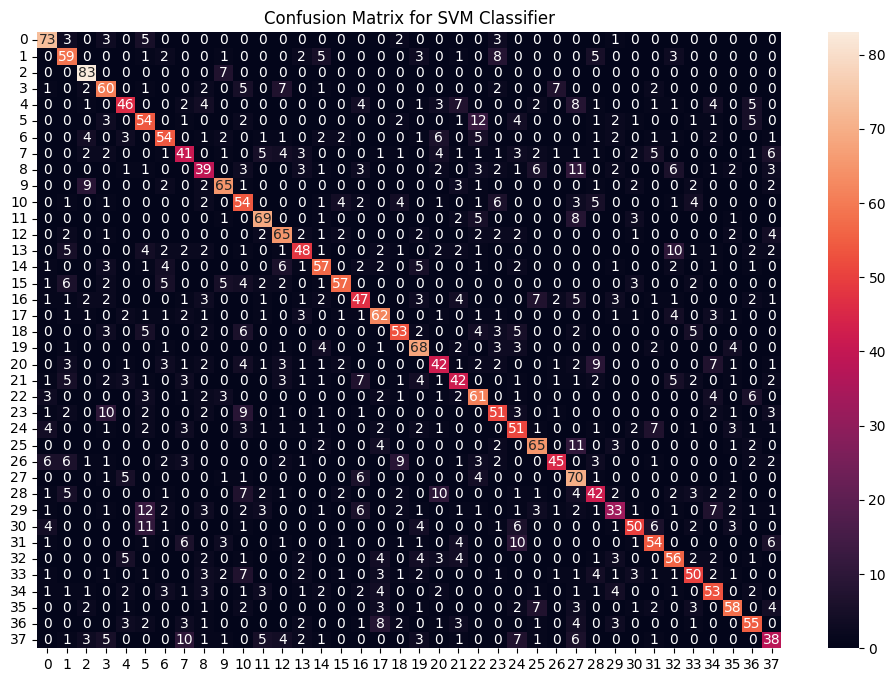

SVM Accuracy: 60.53%


In [84]:
cf_matrix_svm = confusion_matrix(y_resampled, svm_preds)
plt.figure(figsize = (12, 8))
sns.heatmap(cf_matrix_svm, annot = True, fmt = "d")
plt.title("Confusion Matrix for SVM Classifier")
plt.show()

print(f"SVM Accuracy: {accuracy_score(y_resampled, svm_preds) * 100:.2f}%")

In [90]:
nb_model =  GaussianNB()
nb_model.fit(X_resampleed, y_resampled)
nb_preds = nb_model.predict(X_resampleed)

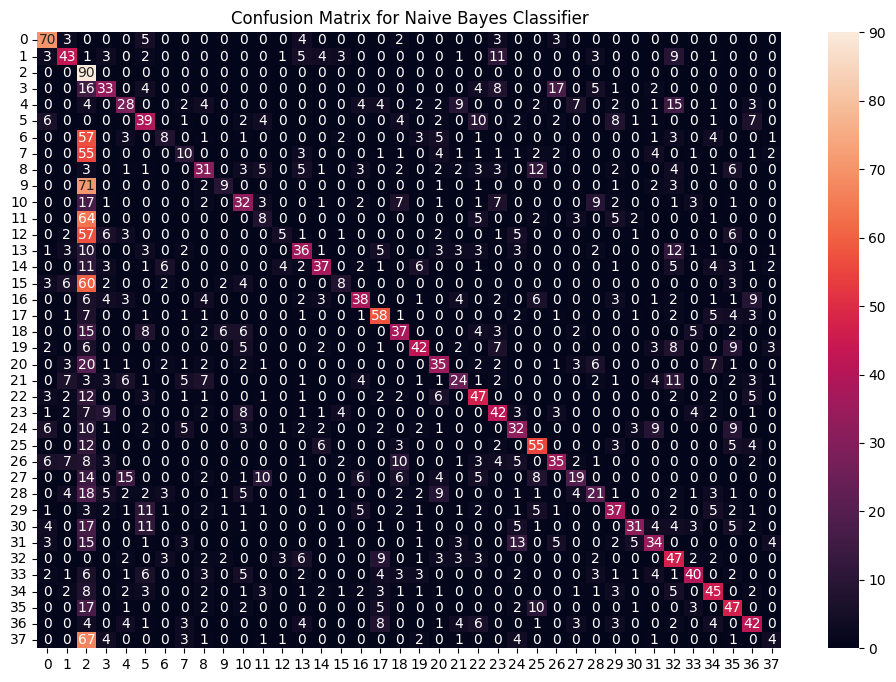

Naive Bayes Accuracy:  37.98%


In [100]:
cf_matrix_nb = confusion_matrix(y_resampled, nb_preds)
plt.figure(figsize = (12, 8))
sns.heatmap(cf_matrix_nb, annot = True, fmt = 'd' )
plt.title('Confusion Matrix for Naive Bayes Classifier')
plt.show()

print(f"Naive Bayes Accuracy: {accuracy_score(y_resampled, nb_preds) * 100: .2f}%")

In [104]:
dt_model = DecisionTreeClassifier()
dt_model.fit(X_resampleed, y_resampled)
dt_preds = dt_model.predict(X_resampleed)

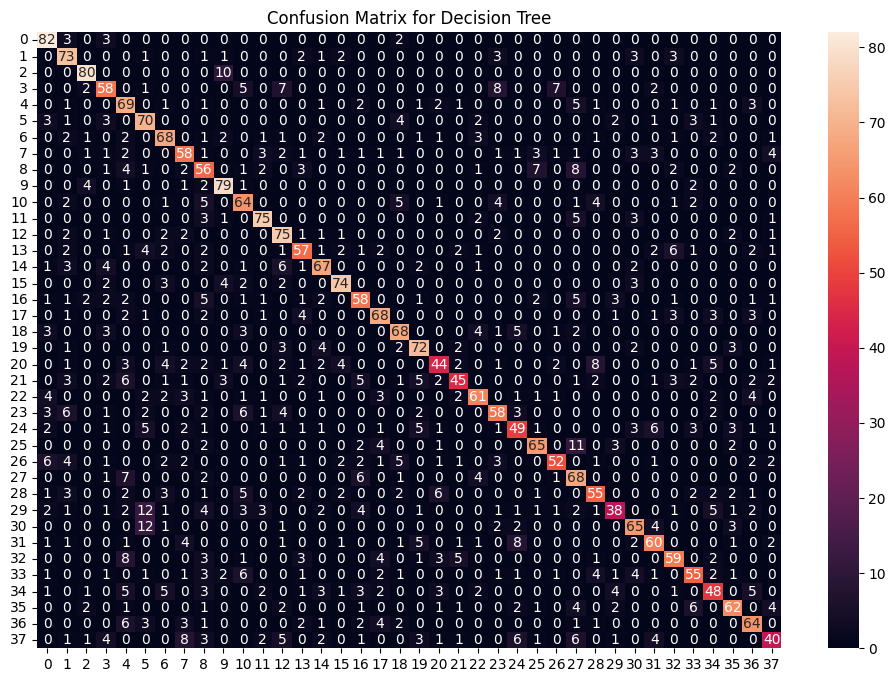

Decision Tree Accuracy: 68.98%


In [116]:
cf_matrix_dt = confusion_matrix(y_resampled, dt_preds)
plt.figure(figsize = (12,8))
sns.heatmap(cf_matrix_dt, annot = True, fmt = 'd')
plt.title("Confusion Matrix for Decision Tree")
plt.show()

print(f"Decision Tree Accuracy: {accuracy_score(y_resampled, dt_preds) * 100:.2f}%")

In [118]:
rf_model = RandomForestClassifier()
rf_model.fit(X_resampleed, y_resampled)
rf_pred = rf_model.predict(X_resampleed)

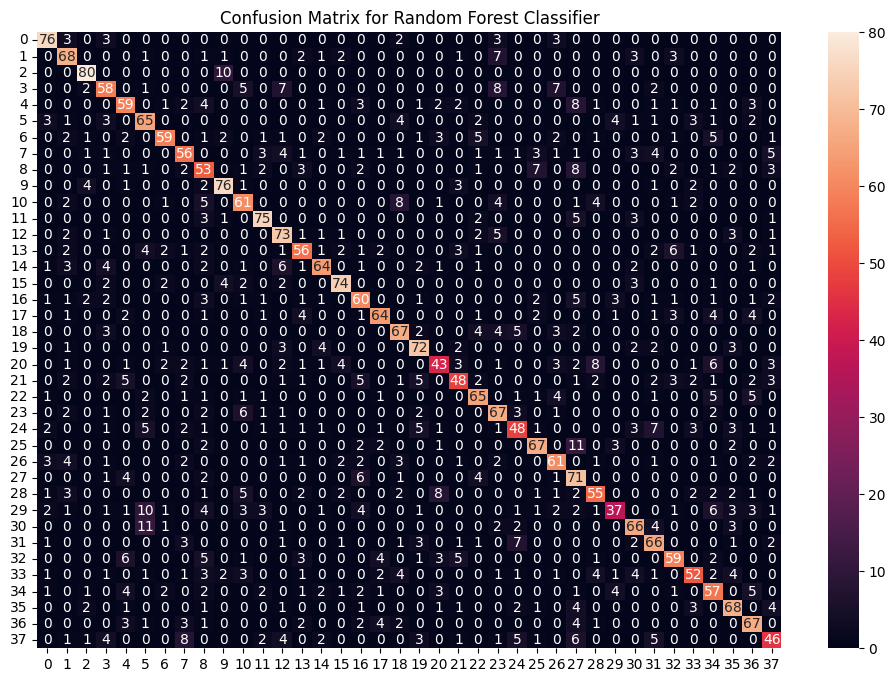

Random Forest Classifier Score: 68.98%


In [122]:
cf_matrix_rf = confusion_matrix(y_resampled, rf_pred)
plt.figure(figsize= (12,8))
sns.heatmap(cf_matrix_rf, annot = True, fmt = 'd')
plt.title('Confusion Matrix for Random Forest Classifier')
plt.show()

print(f"Random Forest Classifier Score: {accuracy_score(y_resampled, rf_pred) * 100:.2f}%")

#### Combining Predictions for Robustness

In [129]:
from statistics import mode
final_preds = [mode([i,j,k,l]) for i, j, k, l in zip(svm_preds, nb_preds, dt_preds, rf_pred)]

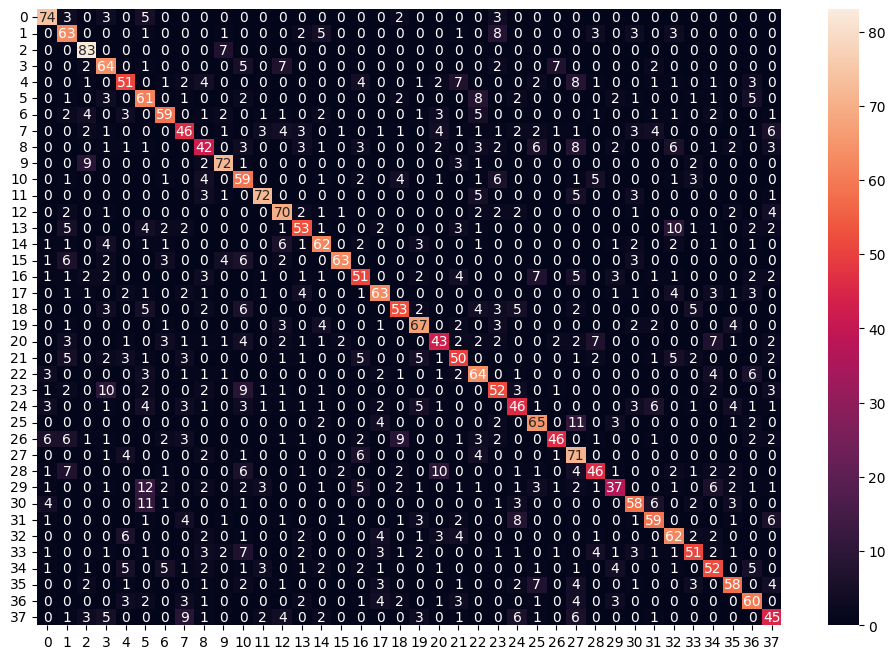

Combined Model Accuracy: 64.12%


In [141]:
cf_matrix_combined = confusion_matrix(y_resampled, final_preds)
plt.figure(figsize= (12, 8))
sns.heatmap(cf_matrix_combined, annot = True, fmt = 'd')
plt.show()

print(f"Combined Model Accuracy: {accuracy_score(y_resampled, final_preds) * 100:.2f}%")

#### Creating Prediction Function

In [164]:
symptoms = X.columns.values
symptom_index = {symptom: idx for idx, symptom in enumerate(symptoms)}

import numpy as np
from scipy.stats import mode

def predict_diseases(input_symptoms):
    input_symptoms = [sym.strip().title() for sym in input_symptoms.split(",")]
    input_data = [0] * len(symptom_index)

    # Map symptoms to vector
    for symptom in input_symptoms:
        if symptom in symptom_index:
            input_data[symptom_index[symptom]] = 1
        else:
            print(f"Warning: Symptom '{symptom}' not recognized.")

    input_data = np.array(input_data).reshape(1, -1)

    # Predict using all models
    svm_pred = svm_model.predict(input_data)[0]
    dt_pred = dt_model.predict(input_data)[0]
    rf_pred = rf_model.predict(input_data)[0]
    nb_pred = nb_model.predict(input_data)[0]

    # Majority vote
    final_pred = mode([svm_pred, dt_pred, rf_pred, nb_pred])[0][0]

    return {
        "Random Forest Classifier": rf_pred,
        "Decision Tree": dt_pred,
        "SVM Prediction": svm_pred,
        "Naive Bayes Prediction": nb_pred,
        "Final Prediction": final_pred
    }

# Example call
print(predict_diseases("Itching,Skin Rash,Nodal Skin Eruptions"))


C:\Users\irt\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\irt\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\irt\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\irt\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


IndexError: invalid index to scalar variable.